# Probing in Code LLMs — Index / Key

In [1]:
# !pip install transformers torch scikit-learn matplotlib seaborn tqdm

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import defaultdict
import re
# need the AST to properly identify subscript expressions
import ast
import warnings
warnings.filterwarnings('ignore')  # suppress the sklearn/tqdm noise — gets annoying fast

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # use GPU if it's there, otherwise fall back to CPU
print(f'Using device: {DEVICE}')

/Applications/Projects/Algoverse/Coding/algoverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'  

print(f'Loading tokenizer and model: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)  # needed for Qwen — it has custom model code

# Qwen has no pad token separate from eos — set one so batched calls don't warn
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token  # Qwen has no separate pad token, eos works fine here

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True, trust_remote_code=True)  # needed for Qwen — it has custom model code
model.eval()  # inference only, no gradients needed
model.to(DEVICE)  # move weights to GPU if available

# grab these once — reuse later
NUM_LAYERS  = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
print(f'Layers: {NUM_LAYERS}, Hidden size: {HIDDEN_SIZE}')

_probe_ids = tokenizer('x', return_tensors='pt')['input_ids'][0].tolist()
_raw_len   = len(tokenizer.tokenize('x'))
LEADING_SPECIAL = len(_probe_ids) - _raw_len   # 1 for BERT, 0 for Qwen
print(f'Leading special tokens detected: {LEADING_SPECIAL}  '
      f'(e.g. [CLS] for BERT=1, none for Qwen=0)')

Loading tokenizer and model: Qwen/Qwen2.5-1.5B ...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 6307.73it/s]

Layers: 28, Hidden size: 1536
Leading special tokens detected: 0  (e.g. [CLS] for BERT=1, none for Qwen=0)



## Dataset 

In [3]:
import os, json

# adjust this path if the data is somewhere else
XLCOST_ROOT    = '/Applications/Projects/Algoverse/CODING/XLCoST_data'
NL2CODE_PROG   = os.path.join(XLCOST_ROOT, 'retrieval', 'nl2code_search', 'program_level')


def reconstruct_code(tokens):  # XLCoST stores code as token lists with indent markers
    indent_level = 0
    lines        = []
    current_line = []

    for tok in tokens:
        if tok == 'NEW_LINE':  # XLCoST encodes newlines as explicit tokens
            lines.append('    ' * indent_level + ' '.join(current_line))
            current_line = []
        elif tok == 'INDENT':  # indentation is tracked via these special tokens
            indent_level += 1
        elif tok == 'DEDENT':
            indent_level = max(0, indent_level - 1)
        else:
            current_line.append(tok)

    if current_line:   # flush any trailing content without a NEW_LINE
        lines.append('    ' * indent_level + ' '.join(current_line))

    return '\n'.join(lines).strip()


def load_xlcost_programs(language, split='train', max_programs=300):  # cap how many programs we load — enough for a good sample
    path = os.path.join(NL2CODE_PROG, language, f'{split}.jsonl')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')

    programs = []
    with open(path) as f:
        for line in f:
            if len(programs) >= max_programs:  # cap how many programs we load — enough for a good sample
                break
            rec  = json.loads(line.strip())  # each line in the .jsonl is one program
            code = reconstruct_code(rec['code_tokens'])  # XLCoST stores code as token lists with indent markers
            if code:
                programs.append(code)
    return programs


print('Loading Python programs from XLCoST (program_level) ...')
PYTHON_PROGRAMS    = load_xlcost_programs('Python', split='train', max_programs=500)  # cap how many programs we load — enough for a good sample
INDEX_KEY_SNIPPETS = PYTHON_PROGRAMS
print(f'Loaded {len(PYTHON_PROGRAMS)} Python programs')

print('\n── Sample program #0 ──────────────────────────────────────────')
print(PYTHON_PROGRAMS[0])
print('\n── Sample program #1 ──────────────────────────────────────────')
print(PYTHON_PROGRAMS[1][:400])

Loading Python programs from XLCoST (program_level) ...
Loaded 500 Python programs

── Sample program #0 ──────────────────────────────────────────
def maxPresum ( a , b ) :
    X = max ( a [ 0 ] , 0 )
    for i in range ( 1 , len ( a ) ) :
        a [ i ] += a [ i - 1 ]
        X = max ( X , a [ i ] )
    Y = max ( b [ 0 ] , 0 )
    for i in range ( 1 , len ( b ) ) :
        b [ i ] += b [ i - 1 ]
        Y = max ( Y , b [ i ] )
    return X + Y
A = [ 2 , - 1 , 4 , - 5 ]
B = [ 4 , - 3 , 12 , 4 , - 3 ]
print ( maxPresum ( A , B ) )

── Sample program #1 ──────────────────────────────────────────
import math
def sumOfTwoCubes ( n ) :
    lo = 1
    hi = round ( math . pow ( n , 1 / 3 ) )
    while ( lo <= hi ) :
        curr = ( lo * lo * lo + hi * hi * hi )
        if ( curr == n ) :
            return True
        if ( curr < n ) :
            lo += 1
        else :
            hi -= 1
    return False
N = 28
if ( sumOfTwoCubes ( N ) ) :
    print ( " True " )
else :
    print ( " Fal

In [4]:
def maxPresum ( a , b ) :
    X = max ( a [ 0 ] , 0 )
    for i in range ( 1 , len ( a ) ) :
        a [ i ] += a [ i - 1 ]
        X = max ( X , a [ i ] )
    Y = max ( b [ 0 ] , 0 )
    for i in range ( 1 , len ( b ) ) :
        b [ i ] += b [ i - 1 ]
        Y = max ( Y , b [ i ] )
    return X + Y
A = [ 2 , - 1 , 4 , - 5 ]
B = [ 4 , - 3 , 12 , 4 , - 3 ]
print ( maxPresum ( A , B ) )

22


## Tokenization

In [5]:
def show_tokens(code_str, n_show=15):
    """Tokenize a code string and display token ID → string mapping."""
    tokens = tokenizer.tokenize(code_str)
    ids    = tokenizer.convert_tokens_to_ids(tokens)
    print(f'Code: {repr(code_str[:80])}')
    print(f'Tokens ({len(tokens)} total):')
    for tok, tid in zip(tokens[:n_show], ids[:n_show]):
        print(f'  {tid:>8}  {repr(tok)}')
    print()

print('=== INDEX/KEY EXAMPLE ===')
show_tokens('val = arr[i]\nd[key] = d.get(key, 0) + 1\nresult = matrix[row][col]')

=== INDEX/KEY EXAMPLE ===
Code: 'val = arr[i]\nd[key] = d.get(key, 0) + 1\nresult = matrix[row][col]'
Tokens (27 total):
       831  'val'
       284  'Ġ='
      2890  'Ġarr'
       989  '[i'
       921  ']Ċ'
        67  'd'
      8157  '[key'
        60  ']'
       284  'Ġ='
       294  'Ġd'
       670  '.get'
      4857  '(key'
        11  ','
       220  'Ġ'
        15  '0'



In [6]:
# Check how the tokenizer handles index/key patterns specifically
# This is important for Qwen which merges '[' with the following variable
test_cases = [
    'arr[i]',
    'matrix[row][col]',
    'd[key]',
    'cache[n]',
    'arr[i] = arr[j]',
]

print(f'{"Code":30s}  Tokens')
print('-' * 70)
for code in test_cases:
    toks = tokenizer.tokenize(code)
    print(f'{code!r:30s}  {toks}')

print()

Code                            Tokens
----------------------------------------------------------------------
'arr[i]'                        ['arr', '[i', ']']
'matrix[row][col]'              ['matrix', '[row', '][', 'col', ']']
'd[key]'                        ['d', '[key', ']']
'cache[n]'                      ['cache', '[n', ']']
'arr[i] = arr[j]'               ['arr', '[i', ']', 'Ġ=', 'Ġarr', '[j', ']']




## Token Labeling (Rule Based)

- **1** = this token is a variable used as an index or key inside a subscript (`arr[i]`, `d[key]`)
- **0** = everything else

In [7]:
# need the AST to properly identify subscript expressions
import ast

def get_index_key_names(code):
    """
    Returns the set of variable names used as indices or keys inside subscript
    expressions in Python code.

    Captures:
      arr[i]        →  i
      d[key]        →  key
      matrix[row][col]  →  row, col
      cache[n]      →  n

    Excludes:
      arr[-1]       (negative integer literal — not a variable)
      arr[0]        (integer literal)
      arr[1:3]      (slice — not a single-variable index)
    """
    indices = set()
    try:
        tree = ast.parse(code)  # AST is more reliable than regex for finding subscripts
    except SyntaxError:
        return indices

    for node in ast.walk(tree):
        if isinstance(node, ast.Subscript):  # subscript nodes cover both arr[i] and d[key]
            slc = node.slice
            # Python < 3.9 wraps slice in an ast.Index node
            if isinstance(slc, ast.Index):  # Python <3.9 wraps slice in an Index node, 3.9+ doesn't
                slc = slc.value
            if isinstance(slc, ast.Name):  # only care about variable names, not literals like arr[0]
                indices.add(slc.id)
    return indices


# Quick verification
test_code = '''
total = 0
for i in range(n):
    total += arr[i]
d[key] = d.get(key, 0) + 1
result = matrix[row][col]
last = arr[-1]
'''
print('Index/Key names found:', get_index_key_names(test_code))

Index/Key names found: {'key', 'row', 'i', 'col'}


In [8]:
def label_tokens(code, target_names, role_name='role'):
    """
    Tokenize `code` and assign a binary label to each token.
    Label = 1 if the token resolves to a target variable name, 0 otherwise.

    Handles tokenizer quirks:
    - BERT:  '##idx' continuation tokens (strip '##')
    - GPT2/Qwen: 'Ġi' space-prefixed tokens (strip 'Ġ')
    - Qwen bracket-merging: '[i' or 'i]' (strip leading '[' / trailing ']')
      e.g. tokenizer may merge arr[i] → ['arr', '[i', ']']
           so '[i' must match target name 'i'

    Returns:
        tokens: list of token strings
        labels: list of int (0 or 1)
    """
    if not target_names:  # nothing to label if no index vars were found
        return [], []

    tokens = tokenizer.tokenize(code)
    labels = []
    for tok in tokens:
        is_continuation = tok.startswith('##')       # BERT sub-word
        # Strip space-prefix markers (GPT2/Qwen use Ġ, sentencepiece uses ▁)
        clean = tok.lstrip('Ġ▁Ā').lstrip('##')  # GPT-style tokenizers prefix spaces with Ġ
        # Strip bracket characters that Qwen often merges with the variable:
        # e.g. '[i' → 'i',  'i]' → 'i',  '[key]' → 'key'
        clean_inner = clean.strip('[]().,;:')
        matched = (not is_continuation) and (clean in target_names or clean_inner in target_names)
        labels.append(1 if matched else 0)

    return tokens, labels


# ── Verify on the known Qwen tokenization quirk ──────────────────────────────
code     = 'for i in range(n):\n    total += arr[i]\nd[key] = d.get(key, 0) + 1'
idx_names = get_index_key_names(code)
toks, labs = label_tokens(code, idx_names, 'index_key')

print(f'Index/key names detected by AST: {idx_names}')
print(f'\n{"Token":20s}  Label')
print('-' * 38)
for tok, lab in zip(toks, labs):
    marker = '  <-- INDEX/KEY' if lab == 1 else ''
    print(f'{repr(tok):20s}  {lab}{marker}')

print(f'\nPositive tokens: {sum(labs)} / {len(labs)}')

Index/key names detected by AST: {'key', 'i'}

Token                 Label
--------------------------------------
'for'                 0
'Ġi'                  1  <-- INDEX/KEY
'Ġin'                 0
'Ġrange'              0
'(n'                  0
'):Ċ'                 0
'ĠĠĠ'                 0
'Ġtotal'              0
'Ġ+='                 0
'Ġarr'                0
'[i'                  1  <-- INDEX/KEY
']Ċ'                  0
'd'                   0
'[key'                1  <-- INDEX/KEY
']'                   0
'Ġ='                  0
'Ġd'                  0
'.get'                0
'(key'                1  <-- INDEX/KEY
','                   0
'Ġ'                   0
'0'                   0
')'                   0
'Ġ+'                  0
'Ġ'                   0
'1'                   0

Positive tokens: 4 / 26


In [9]:
def build_labeled_dataset(snippets, extract_fn, role_name):
    """
    Given a list of code snippets and a role-extraction function,
    return a list of dicts with tokens and binary labels.
    Skips snippets where no target variables are found.
    """
    dataset = []
    skipped = 0
    for code in snippets:
        target_names = extract_fn(code)
        if not target_names:  # nothing to label if no index vars were found
            skipped += 1
            continue
        tokens, labels = label_tokens(code, target_names, role_name)
        if not tokens or sum(labels) == 0:  # skip programs where none of the index vars survived tokenization
            skipped += 1
            continue
        dataset.append({'code': code, 'tokens': tokens, 'labels': labels,
                        'target_names': target_names, 'role': role_name})

    total_pos = sum(sum(d['labels']) for d in dataset)
    total_tok = sum(len(d['tokens']) for d in dataset)
    print(f'[{role_name:12s}] {len(dataset)} programs with labels, {skipped} skipped')
    print(f'               {total_pos} positive tokens / {total_tok} total '
          f'({100*total_pos/total_tok:.1f}% positive)')
    return dataset


index_data = build_labeled_dataset(INDEX_KEY_SNIPPETS, get_index_key_names, 'index_key')

[index_key   ] 255 programs with labels, 245 skipped
               3747 positive tokens / 64536 total (5.8% positive)


In [10]:
def show_labeled_snippet(sample):
    print(f"Role: {sample['role']} | Target vars: {sample['target_names']}")
    print(f"Code:\n{sample['code'][:400]}")
    print('\nTokens + labels (first 50):')
    for tok, lab in list(zip(sample['tokens'], sample['labels']))[:50]:
        marker = '  <-- INDEX/KEY' if lab == 1 else ''
        print(f'  {repr(tok):20s} {lab}{marker}')
    print()

show_labeled_snippet(index_data[0])

Role: index_key | Target vars: {'i'}
Code:
def maxPresum ( a , b ) :
    X = max ( a [ 0 ] , 0 )
    for i in range ( 1 , len ( a ) ) :
        a [ i ] += a [ i - 1 ]
        X = max ( X , a [ i ] )
    Y = max ( b [ 0 ] , 0 )
    for i in range ( 1 , len ( b ) ) :
        b [ i ] += b [ i - 1 ]
        Y = max ( Y , b [ i ] )
    return X + Y
A = [ 2 , - 1 , 4 , - 5 ]
B = [ 4 , - 3 , 12 , 4 , - 3 ]
print ( maxPresum ( A , B ) )

Tokens + labels (first 50):
  'def'                0
  'Ġmax'               0
  'Pres'               0
  'um'                 0
  'Ġ('                 0
  'Ġa'                 0
  'Ġ,'                 0
  'Ġb'                 0
  'Ġ)'                 0
  'Ġ:Ċ'                0
  'ĠĠĠ'                0
  'ĠX'                 0
  'Ġ='                 0
  'Ġmax'               0
  'Ġ('                 0
  'Ġa'                 0
  'Ġ['                 0
  'Ġ'                  0
  '0'                  0
  'Ġ]'                 0
  'Ġ,'                 0
  'Ġ'        


## Hidden State Extraction

In [11]:
# progress bars — helpful when extraction takes a while
from tqdm.auto import tqdm

# anything longer than this gets truncated
MAX_SEQ_LEN = 512

def extract_hidden_states(dataset):
    all_hidden     = defaultdict(list)
    all_labels     = []
    all_token_strs = []

    with torch.no_grad():  # saves memory — we're not doing any backprop
        for sample in tqdm(dataset, desc='Extracting hidden states'):
            code   = sample['code']
            labels = sample['labels']

            encoding = tokenizer(
                code,
                return_tensors='pt',
                truncation=True,
                max_length=MAX_SEQ_LEN,
                padding=False,  # no padding since we're processing one at a time
            ).to(DEVICE)

            # encoded_len is the actual post-truncation sequence length.
            # Use this as ground truth — tokenizer.tokenize(code) gives pre-truncation
            # count which is wrong when programs are longer than MAX_SEQ_LEN.
            encoded_len = encoding['input_ids'].shape[1]  # actual length after truncation — not the same as pre-tokenize count
            n_content   = encoded_len - LEADING_SPECIAL   # 0 for Qwen, 1 for BERT (CLS)

            tokens_no_special = tokenizer.tokenize(code)
            labels_trunc = labels[:n_content]
            tokens_trunc = tokens_no_special[:n_content]

            outputs       = model(**encoding)
            hidden_states = outputs.hidden_states  # tuple: one tensor per layer

            start = LEADING_SPECIAL
            end   = start + n_content

            for layer_idx, layer_hs in enumerate(hidden_states):
                # .float() casts bfloat16 → float32 before converting to numpy.
                # Qwen (and many modern LLMs) use bfloat16 by default; numpy
                # does not support bfloat16 and raises TypeError without this cast.
                content_hs = layer_hs[0, start:end, :].float().cpu().numpy()  # Qwen uses bfloat16 by default — numpy can't handle it, cast first
                for vec in content_hs:
                    all_hidden[layer_idx].append(vec)  # accumulate per layer — will stack into an array at the end

            all_labels.extend(labels_trunc)
            all_token_strs.extend(tokens_trunc)

    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.stack(all_hidden[layer_idx])  # convert list of vectors to a proper 2D array

    return all_hidden, np.array(all_labels), all_token_strs


print('Extracting hidden states for index/key role...')
idx_hidden, idx_labels, idx_tokens = extract_hidden_states(index_data)
print(f'Shape at layer 0: {idx_hidden[0].shape}')
print(f'Label distribution: {np.bincount(idx_labels)}  (0 = non-index, 1 = index/key)')

Extracting hidden states for index/key role...


Extracting hidden states: 100%|██████████| 255/255 [34:23<00:00,  8.09s/it]


Shape at layer 0: (63851, 1536)
Label distribution: [60114  3737]  (0 = non-index, 1 = index/key)


In [12]:
# ── Class distribution & imbalance check ─────────────────────────────────────
counts    = np.bincount(idx_labels)
total     = len(idx_labels)
n_neg, n_pos = counts[0], counts[1]
print('Class distribution (all tokens):')
print(f'  Non-index (0): {n_neg:>7,}  ({100*n_neg/total:.1f}%)')
print(f'  Index/Key (1): {n_pos:>7,}  ({100*n_pos/total:.1f}%)')
print(f'  Imbalance ratio: {n_neg/n_pos:.1f}:1  (non-index : index)')
print()
# Baseline accuracy a naive 'always predict 0' classifier would achieve
print(f'  Naive all-zero baseline accuracy: {100*n_neg/total:.1f}%')
print('  (If probe accuracy is close to this, the probe has learned nothing useful.)')


Class distribution (all tokens):
  Non-index (0):  60,114  (94.1%)
  Index/Key (1):   3,737  (5.9%)
  Imbalance ratio: 16.1:1  (non-index : index)

  Naive all-zero baseline accuracy: 94.1%
  (If probe accuracy is close to this, the probe has learned nothing useful.)


## Probe Training

In [13]:
def train_probes(hidden_states_by_layer, labels, test_size=0.2, random_state=42):  # 80/20 split
    
    n = len(labels)
    train_idx, test_idx = train_test_split(
        np.arange(n), test_size=test_size, random_state=random_state, stratify=labels  # make sure both train and test have the same class ratio
    )

    results = {}
    for layer_idx in tqdm(sorted(hidden_states_by_layer.keys()), desc='Training probes'):
        X = hidden_states_by_layer[layer_idx]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        clf = LogisticRegression(max_iter=1000, class_weight='balanced',  # index tokens are ~6% of all tokens — need to reweight or probe ignores them
                                 random_state=random_state, C=1.0)  # standard regularization, didn't tune this
        clf.fit(X_train, y_train)

        y_train_pred = clf.predict(X_train)
        y_test_pred  = clf.predict(X_test)
        results[layer_idx] = {
            'train_acc': accuracy_score(y_train, y_train_pred),
            'test_acc':  accuracy_score(y_test,  y_test_pred),
            'train_f1':  f1_score(y_train, y_train_pred, average='macro'),  # macro F1 is fairer given the class imbalance
            'test_f1':   f1_score(y_test,  y_test_pred,  average='macro'),  # macro F1 is fairer given the class imbalance
            'probe':     clf,
            'test_idx':  test_idx,
        }
    return results


print('Training probes for index/key role...')
idx_results = train_probes(idx_hidden, idx_labels)

Training probes for index/key role...


Training probes: 100%|██████████| 29/29 [13:23<00:00, 27.71s/it]


## Evaluation & Visualization

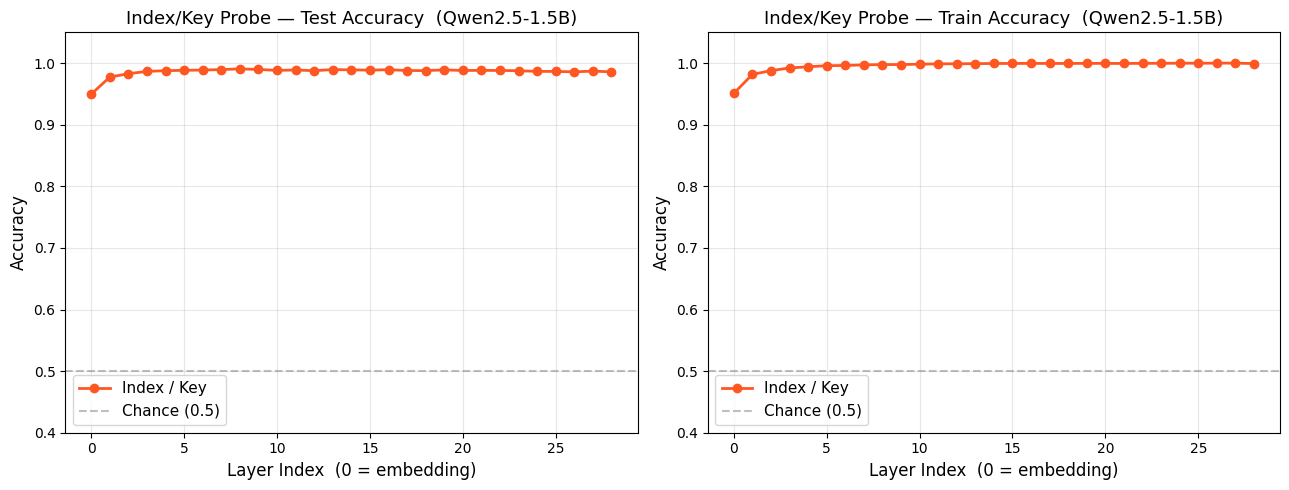

Saved: probe_accuracy_index_key.png


In [14]:
layers     = sorted(idx_results.keys())
test_accs  = [idx_results[l]['test_acc']  for l in layers]
train_accs = [idx_results[l]['train_acc'] for l in layers]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, accs, title in zip(axes,
                            [test_accs, train_accs],
                            ['Test Accuracy', 'Train Accuracy']):
    ax.plot(layers, accs, marker='o', color='#FF5722', linewidth=2, label='Index / Key')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')  # chance-level for a balanced binary probe
    ax.set_xlabel('Layer Index  (0 = embedding)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'Index/Key Probe — {title}  ({MODEL_NAME.split("/")[-1]})', fontsize=13)
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible

plt.tight_layout()
plt.savefig('probe_accuracy_index_key.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: probe_accuracy_index_key.png')

In [15]:
print(f'{"Layer":>7}  {"Train Acc":>10}  {"Test Acc":>10}  {"Train F1":>10}  {"Test F1":>10}')
print('-' * 60)
for l in layers:
    print(f'{l:>7}  {idx_results[l]["train_acc"]:>10.3f}  {idx_results[l]["test_acc"]:>10.3f}  {idx_results[l]["train_f1"]:>10.3f}  {idx_results[l]["test_f1"]:>10.3f}')

  Layer   Train Acc    Test Acc    Train F1     Test F1
------------------------------------------------------------
      0       0.951       0.950       0.838       0.836
      1       0.982       0.977       0.928       0.912
      2       0.988       0.983       0.950       0.930
      3       0.992       0.987       0.966       0.944
      4       0.994       0.988       0.974       0.948
      5       0.996       0.988       0.982       0.951
      6       0.996       0.989       0.983       0.952
      7       0.997       0.990       0.987       0.955
      8       0.998       0.991       0.990       0.959
      9       0.998       0.990       0.990       0.955
     10       0.998       0.988       0.992       0.949
     11       0.999       0.989       0.995       0.951
     12       0.999       0.988       0.995       0.946
     13       0.999       0.990       0.996       0.954
     14       0.999       0.989       0.997       0.952
     15       0.999       0.989       0.998

In [16]:
best_layer = max(idx_results, key=lambda l: idx_results[l]['test_acc'])
test_idx   = idx_results[best_layer]['test_idx']
clf        = idx_results[best_layer]['probe']

X_test = idx_hidden[best_layer][test_idx]
y_test = idx_labels[test_idx]
y_pred = clf.predict(X_test)

print(f'Best layer: {best_layer}  (test acc: {idx_results[best_layer]["test_acc"]:.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['non-index', 'index_key']))

Best layer: 8  (test acc: 0.991)

              precision    recall  f1-score   support

   non-index       1.00      0.99      1.00     12024
   index_key       0.89      0.96      0.92       747

    accuracy                           0.99     12771
   macro avg       0.94      0.98      0.96     12771
weighted avg       0.99      0.99      0.99     12771



In [17]:
# ── Confusion matrix for best layer ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print('Confusion matrix (best layer, test set):')
print(f'  True  Negatives (TN): {tn:>6,}  correctly predicted non-index')
print(f'  False Positives (FP): {fp:>6,}  non-index predicted as index')
print(f'  False Negatives (FN): {fn:>6,}  index missed')
print(f'  True  Positives (TP): {tp:>6,}  correctly predicted index')
print()
print(f'  TPR (recall):    {tp/(tp+fn):.3f}')
print(f'  FPR:             {fp/(fp+tn):.3f}')
print(f'  Precision:       {tp/(tp+fp):.3f}')
print(f'  Pred positive rate: {(tp+fp)/len(y_test):.3f}  (vs true positive rate {(tp+fn)/len(y_test):.3f} in test set)')


Confusion matrix (best layer, test set):
  True  Negatives (TN): 11,934  correctly predicted non-index
  False Positives (FP):     90  non-index predicted as index
  False Negatives (FN):     29  index missed
  True  Positives (TP):    718  correctly predicted index

  TPR (recall):    0.961
  FPR:             0.007
  Precision:       0.889
  Pred positive rate: 0.063  (vs true positive rate 0.058 in test set)



## Cross-Language Generalization

In [18]:
import re

print('Loading Java programs from XLCoST (program_level) ...')
JAVA_PROGRAMS = load_xlcost_programs('Java', split='train', max_programs=300)  # cap how many programs we load — enough for a good sample
print(f'Loaded {len(JAVA_PROGRAMS)} Java programs')

print('\n── Sample Java program ─────────────────────────────────────────')
print(JAVA_PROGRAMS[0][:500])


def get_java_index_key_names(code):
    """
    Returns variable names used as array indices or map keys in Java code.
    Captures: arr[i], dp[j], grid[row][col], map.get(key)
    Excludes: integer literals like arr[0]
    """
    indices = set()
    for m in re.finditer(r'\[\s*([a-zA-Z_]\w*)\s*\]', code):
        indices.add(m.group(1))
    for m in re.finditer(r'\.(?:get|containsKey|getOrDefault)\(\s*([a-zA-Z_]\w*)', code):
        indices.add(m.group(1))
    indices -= {'int', 'long', 'char', 'byte', 'short', 'boolean',
                'String', 'Integer', 'Long', 'Object', 'null', 'true', 'false'}
    return indices


java_index_data = []
skipped = 0
for code in JAVA_PROGRAMS:
    names = get_java_index_key_names(code)
    if not names:
        skipped += 1
        continue
    tokens, labels = label_tokens(code, names, 'index_key')
    if tokens and sum(labels) > 0:
        java_index_data.append({
            'code': code, 'tokens': tokens, 'labels': labels,
            'target_names': names, 'role': 'index_key_java',
        })
    else:
        skipped += 1

print(f'\nJava index/key programs with labels: {len(java_index_data)} ({skipped} skipped)')

if java_index_data:
    sample = java_index_data[0]
    print(f"\nTarget vars: {sample['target_names']}")
    print(f"Code:\n{sample['code'][:400]}")
    print('\nLabeled tokens (first 40):')
    for tok, lab in list(zip(sample['tokens'], sample['labels']))[:40]:
        marker = '  <-- INDEX/KEY' if lab == 1 else ''
        print(f'  {repr(tok):20s} {lab}{marker}')

Loading Java programs from XLCoST (program_level) ...
Loaded 300 Java programs

── Sample Java program ─────────────────────────────────────────
import java . util . * ; class GFG { static int maxPresum ( int [ ] a , int [ ] b ) { int X = Math . max ( a [ 0 ] , 0 ) ; for ( int i = 1 ; i < a . length ; i ++ ) { a [ i ] += a [ i - 1 ] ; X = Math . max ( X , a [ i ] ) ; } int Y = Math . max ( b [ 0 ] , 0 ) ; for ( int i = 1 ; i < b . length ; i ++ ) { b [ i ] += b [ i - 1 ] ; Y = Math . max ( Y , b [ i ] ) ; } return X + Y ; } public static void main ( String [ ] args ) { int [ ] A = { 2 , - 1 , 4 , - 5 } ; int [ ] B = { 4 , - 3 , 12 , 4 , 

Java index/key programs with labels: 100 (200 skipped)

Target vars: {'i'}
Code:
import java . util . * ; class GFG { static int maxPresum ( int [ ] a , int [ ] b ) { int X = Math . max ( a [ 0 ] , 0 ) ; for ( int i = 1 ; i < a . length ; i ++ ) { a [ i ] += a [ i - 1 ] ; X = Math . max ( X , a [ i ] ) ; } int Y = Math . max ( b [ 0 ] , 0 ) ; for ( in

In [19]:
print('Extracting hidden states for Java index/key programs...')
java_idx_hidden, java_idx_labels, java_idx_tokens = extract_hidden_states(java_index_data)
print(f'Java tokens: {len(java_idx_labels)}, positive: {sum(java_idx_labels)}')

Extracting hidden states for Java index/key programs...


Extracting hidden states:  26%|██▌       | 26/100 [05:10<14:44, 11.95s/it]


KeyboardInterrupt: 

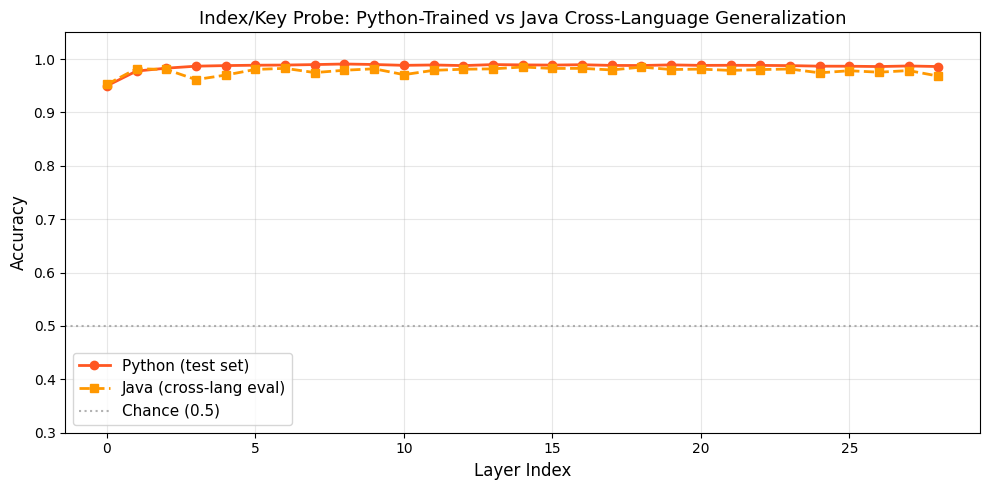

Saved: cross_language_index_key.png

  Layer   Python test   Java cross-lang
----------------------------------------
      0         0.950             0.952
      1         0.977             0.982
      2         0.983             0.980
      3         0.987             0.961
      4         0.988             0.970
      5         0.988             0.980
      6         0.989             0.983
      7         0.990             0.975
      8         0.991             0.979
      9         0.990             0.982
     10         0.988             0.971
     11         0.989             0.979
     12         0.988             0.981
     13         0.990             0.982
     14         0.989             0.985
     15         0.989             0.982
     16         0.989             0.983
     17         0.988             0.980
     18         0.988             0.985
     19         0.989             0.980
     20         0.988             0.981
     21         0.988             0.979
  

In [23]:
def cross_language_eval(source_results, target_hidden, target_labels):  # apply the Python-trained probe directly — no retraining
    """Apply Python-trained probes to target language hidden states."""
    return {
        layer_idx: accuracy_score(target_labels, source_results[layer_idx]['probe'].predict(target_hidden[layer_idx]))
        for layer_idx in sorted(source_results.keys())
    }


cross_accs = cross_language_eval(idx_results, java_idx_hidden, java_idx_labels)  # apply the Python-trained probe directly — no retraining

layers   = sorted(idx_results.keys())
py_test  = [idx_results[l]['test_acc'] for l in layers]
java_acc = [cross_accs[l] for l in layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, py_test,  marker='o', color='#FF5722', linewidth=2, label='Python (test set)')
ax.plot(layers, java_acc, marker='s', color='#FF9800', linewidth=2, linestyle='--',
        label='Java (cross-lang eval)')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='Chance (0.5)')  # chance-level for a balanced binary probe
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Index/Key Probe: Python-Trained vs Java Cross-Language Generalization', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
plt.tight_layout()
plt.savefig('cross_language_index_key.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: cross_language_index_key.png')

print(f'\n{"Layer":>7}  {"Python test":>12}  {"Java cross-lang":>16}')
print('-' * 40)
for l in layers:
    print(f'{l:>7}  {idx_results[l]["test_acc"]:>12.3f}  {cross_accs[l]:>16.3f}')

Training Java-specific index/key probes...


Training probes: 100%|██████████| 29/29 [00:38<00:00,  1.33s/it]


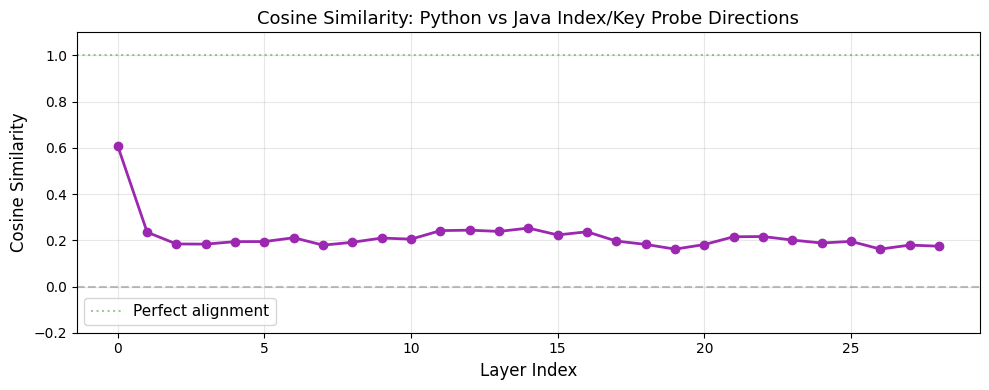


Cosine similarities by layer:
  Layer  0: 0.6069
  Layer  1: 0.2350
  Layer  2: 0.1841
  Layer  3: 0.1834
  Layer  4: 0.1942
  Layer  5: 0.1945
  Layer  6: 0.2111
  Layer  7: 0.1790
  Layer  8: 0.1914
  Layer  9: 0.2098
  Layer 10: 0.2049
  Layer 11: 0.2419
  Layer 12: 0.2438
  Layer 13: 0.2384
  Layer 14: 0.2528
  Layer 15: 0.2232
  Layer 16: 0.2369
  Layer 17: 0.1966
  Layer 18: 0.1822
  Layer 19: 0.1618
  Layer 20: 0.1816
  Layer 21: 0.2153
  Layer 22: 0.2163
  Layer 23: 0.2011
  Layer 24: 0.1883
  Layer 25: 0.1953
  Layer 26: 0.1619
  Layer 27: 0.1791
  Layer 28: 0.1745


In [24]:
from numpy.linalg import norm

if len(java_idx_labels) >= 20 and sum(java_idx_labels) >= 5:
    print('Training Java-specific index/key probes...')
    java_idx_results = train_probes(java_idx_hidden, java_idx_labels)

    similarities = []
    for layer in layers:
        w_py   = idx_results[layer]['probe'].coef_[0]
        w_java = java_idx_results[layer]['probe'].coef_[0]
        similarities.append(np.dot(w_py, w_java) / (norm(w_py) * norm(w_java)))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(layers, similarities, marker='o', color='#9C27B0', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)  # zero line for reference
    ax.axhline(1, color='green', linestyle=':', alpha=0.4, label='Perfect alignment')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title('Cosine Similarity: Python vs Java Index/Key Probe Directions', fontsize=13)
    ax.set_ylim(-0.2, 1.1)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
    plt.tight_layout()
    plt.savefig('probe_cosine_similarity_index_key.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
    plt.show()

    print('\nCosine similarities by layer:')
    for l, s in zip(layers, similarities):
        print(f'  Layer {l:2d}: {s:.4f}')
else:
    print('Not enough Java data for separate probe training.')

## Extended Cross-Language Evaluation — C++, C, C#, JavaScript, PHP

In [25]:
# ── Per-language index/key extractors ────────────────────────────────────────

_C_KEYWORDS = {
    'int', 'long', 'char', 'short', 'float', 'double', 'unsigned', 'void',
    'size_t', 'bool', 'true', 'false', 'null', 'NULL',
}
_JAVA_KEYWORDS = {
    'int', 'long', 'char', 'byte', 'short', 'boolean', 'float', 'double',
    'String', 'Integer', 'Long', 'Object', 'null', 'true', 'false',
}
_CSHARP_KEYWORDS = {
    'int', 'long', 'char', 'byte', 'short', 'bool', 'float', 'double',
    'string', 'object', 'null', 'true', 'false', 'var',
}
_JS_KEYWORDS = {
    'undefined', 'null', 'true', 'false', 'NaN', 'Infinity',
    'length', 'prototype', 'constructor',
}

_BRACKET_RE = re.compile(r'\[\s*([a-zA-Z_]\w*)\s*\]')


def _bracket_names(code, extra_re=None, exclude=None):
    """Shared helper: find variable names inside [ ] and optional extra patterns."""
    names = {m.group(1) for m in _BRACKET_RE.finditer(code)}
    if extra_re:
        for pattern in extra_re:
            names |= {m.group(1) for m in re.finditer(pattern, code)}
    if exclude:
        names -= exclude
    return names


def get_cpp_index_key_names(code):
    """C++: arr[i], map[key], map.at(key), map.find(key)"""
    return _bracket_names(
        code,
        extra_re=[r'\.(?:at|find|count)\(\s*([a-zA-Z_]\w*)'],
        exclude=_C_KEYWORDS,
    )


def get_c_index_key_names(code):
    """C: arr[i] only (no map type)"""
    return _bracket_names(code, exclude=_C_KEYWORDS)


def get_csharp_index_key_names(code):
    """C#: arr[i], dict[key], dict.TryGetValue(key,...), dict.ContainsKey(key)"""
    return _bracket_names(
        code,
        extra_re=[r'\.(?:TryGetValue|ContainsKey|GetValueOrDefault)\(\s*([a-zA-Z_]\w*)'],
        exclude=_CSHARP_KEYWORDS,
    )


def get_javascript_index_key_names(code):
    """JavaScript: arr[i], obj[key], map.get(key), map.has(key)"""
    return _bracket_names(
        code,
        extra_re=[r'\.(?:get|has|delete)\(\s*([a-zA-Z_]\w*)'],
        exclude=_JS_KEYWORDS,
    )


def get_php_index_key_names(code):
    """PHP: $arr[$i], $dict[$key] — strip $ prefix before returning names."""
    # PHP variables look like $arr [ $i ] after XLCoST tokenization
    php_re = re.compile(r'\[\s*\$([a-zA-Z_]\w*)\s*\]')
    names = {m.group(1) for m in php_re.finditer(code)}
    # Also catch plain bracket access (rare in PHP but present in some XLCoST snippets)
    names |= {m.group(1) for m in _BRACKET_RE.finditer(code)}
    names -= _C_KEYWORDS
    return names


# ── Map: XLCoST language name → extractor function ───────────────────────────
LANG_EXTRACTORS = {
    'Java':       get_java_index_key_names,     # already defined above
    'C++':        get_cpp_index_key_names,
    'C':          get_c_index_key_names,
    'C#':         get_csharp_index_key_names,
    'Javascript': get_javascript_index_key_names,
    'PHP':        get_php_index_key_names,
}

print('Extractors defined for:', list(LANG_EXTRACTORS.keys()))

# ── Quick sanity check on a C++ snippet ──────────────────────────────────────
cpp_test = 'for ( int i = 0 ; i < n ; i ++ ) { dp [ i ] = max ( dp [ i - 1 ] , arr [ i ] ) ; }'
print('C++ test names:', get_cpp_index_key_names(cpp_test))

php_test = 'foreach ( $arr as $key => $val ) { $result [ $key ] = $val + 1 ; }'
print('PHP test names:', get_php_index_key_names(php_test))

Extractors defined for: ['Java', 'C++', 'C', 'C#', 'Javascript', 'PHP']
C++ test names: {'i'}
PHP test names: {'key'}


In [26]:
# ── Load, label, and extract hidden states for all non-Python languages ───────
# Results are stored in lang_data dicts for later comparison

lang_hidden  = {'Python': (idx_hidden,  idx_labels,  idx_tokens)}   # already computed
lang_results = {'Python': idx_results}                                # already computed
lang_cross   = {}   # {lang: {layer: cross-lang accuracy}}
lang_cosine  = {}   # {lang: [cosine similarity per layer]}

OTHER_LANGS = ['C++', 'C', 'C#', 'Javascript', 'PHP']

for lang in OTHER_LANGS:
    print(f'\n{"="*60}')
    print(f'  Language: {lang}')
    print(f'{"="*60}')

    # 1. Load programs
    try:
        programs = load_xlcost_programs(lang, split='train', max_programs=300)  # cap how many programs we load — enough for a good sample
    except FileNotFoundError as e:
        print(f'  Skipping — {e}')
        continue
    print(f'  Loaded {len(programs)} programs')

    # 2. Label
    extractor = LANG_EXTRACTORS[lang]
    data = []
    skipped = 0
    for code in programs:
        names = extractor(code)
        if not names:
            skipped += 1
            continue
        tokens, labels = label_tokens(code, names, 'index_key')
        if tokens and sum(labels) > 0:
            data.append({'code': code, 'tokens': tokens, 'labels': labels,
                         'target_names': names, 'role': f'index_key_{lang}'})
        else:
            skipped += 1

    if not data:
        print(f'  No labeled programs found — skipping')
        continue

    total_pos = sum(sum(d['labels']) for d in data)
    total_tok = sum(len(d['tokens']) for d in data)
    print(f'  {len(data)} programs labeled ({skipped} skipped)')
    print(f'  {total_pos} positive / {total_tok} total ({100*total_pos/total_tok:.1f}%)')

    # 3. Extract hidden states
    print(f'  Extracting hidden states...')
    h, lbs, toks = extract_hidden_states(data)
    lang_hidden[lang] = (h, lbs, toks)
    print(f'  Tokens: {len(lbs)}, positive: {int(sum(lbs))}')

    # 4. Cross-language eval: apply Python-trained probe to this language
    cross = {
        layer: accuracy_score(lbs, idx_results[layer]['probe'].predict(h[layer]))
        for layer in sorted(idx_results.keys())
    }
    lang_cross[lang] = cross

    # 5. Train language-specific probe + cosine similarity
    if sum(lbs) >= 10:
        lang_res = train_probes(h, lbs)
        lang_results[lang] = lang_res
        from numpy.linalg import norm
        sims = []
        for layer in sorted(idx_results.keys()):
            w_py = idx_results[layer]['probe'].coef_[0]
            w_tg = lang_res[layer]['probe'].coef_[0]
            sims.append(np.dot(w_py, w_tg) / (norm(w_py) * norm(w_tg)))  # cosine similarity between probe weight vectors
        lang_cosine[lang] = sims
        print(f'  Cosine similarity @ layer 8: {sims[8]:.4f}')

    print(f'  Done: {lang}')

# Also add Java cross-lang / cosine if not already stored
if 'Java' not in lang_cross:
    lang_cross['Java'] = cross_accs
if 'Java' not in lang_cosine and 'java_idx_results' in dir():
    from numpy.linalg import norm
    sims = []
    for layer in sorted(idx_results.keys()):
        w_py = idx_results[layer]['probe'].coef_[0]
        w_tg = java_idx_results[layer]['probe'].coef_[0]
        sims.append(np.dot(w_py, w_tg) / (norm(w_py) * norm(w_tg)))  # cosine similarity between probe weight vectors
    lang_cosine['Java'] = sims

print('\nAll languages processed:', list(lang_cross.keys()))


  Language: C++
  Loaded 300 programs
  113 programs labeled (187 skipped)
  1549 positive / 28051 total (5.5%)
  Extracting hidden states...


Extracting hidden states: 100%|██████████| 113/113 [07:53<00:00,  4.19s/it]


  Tokens: 27830, positive: 1546


Training probes: 100%|██████████| 29/29 [00:49<00:00,  1.69s/it]


  Cosine similarity @ layer 8: 0.2960
  Done: C++

  Language: C
  Loaded 300 programs
  149 programs labeled (151 skipped)
  3035 positive / 50100 total (6.1%)
  Extracting hidden states...


...

  Cosine similarity @ layer 8: 0.2237
  Done: C#

  Language: Javascript
  Loaded 300 programs
  107 programs labeled (193 skipped)
  1430 positive / 24019 total (6.0%)
  Extracting hidden states...


Extracting hidden states: 100%|██████████| 107/107 [06:42<00:00,  3.76s/it]


  Tokens: 23881, positive: 1429


Training probes: 100%|██████████| 29/29 [00:25<00:00,  1.15it/s]

  Cosine similarity @ layer 8: 0.2849
  Done: Javascript

  Language: PHP
  Loaded 300 programs
  No labeled programs found — skipping

All languages processed: ['C++', 'C', 'C#', 'Javascript', 'Java']


In [32]:
# ── Setup ────────────────────────────────────────────────────────────────────
import subprocess, sys

# Install required packages (quiet)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'plotly', 'kaleido'])

import plotly.graph_objects as go
import plotly.io as pio

# Force browser rendering (avoids nbformat / Jupyter issues)
pio.renderers.default = "browser"

# ── Config ───────────────────────────────────────────────────────────────────
LANG_COLORS = {
    'Java':       '#FF9800',
    'C++':        '#2196F3',
    'C':          '#4CAF50',
    'C#':         '#9C27B0',
    'Javascript': '#F44336',
    'PHP':        '#795548',
}

# Ensure proper numeric sorting of layers
layers = sorted(map(int, idx_results.keys()))

# Python baseline
py_test = [idx_results[l]['test_acc'] for l in layers]

# ── Plot 1: Cross-language accuracy ──────────────────────────────────────────
fig1 = go.Figure()

# Python line
fig1.add_trace(go.Scatter(
    x=layers, y=py_test,
    mode='lines+markers',
    marker=dict(symbol='circle', size=7),
    line=dict(color='black', width=2.5),
    name='Python (train/test)',
))

# Cross-language lines
for lang, cross in lang_cross.items():
    acc = [cross[l] for l in layers]
    fig1.add_trace(go.Scatter(
        x=layers, y=acc,
        mode='lines+markers',
        marker=dict(symbol='square', size=7),
        line=dict(
            color=LANG_COLORS.get(lang, 'gray'),
            width=1.8,
            dash='dash'
        ),
        opacity=0.85,
        name=f'{lang} (cross-lang)',
    ))

# Chance line
fig1.add_hline(
    y=0.5,
    line=dict(color='gray', dash='dot', width=1),
    annotation_text='Chance (0.5)',
    annotation_position='bottom right'
)

# Layout
fig1.update_layout(
    title=f'Index/Key Probe: Python-Trained → All Languages ({MODEL_NAME.split("/")[-1]})',
    xaxis_title='Layer Index (0 = embedding)',
    yaxis_title='Accuracy',
    yaxis=dict(range=[0.3, 1.05]),
    legend=dict(
        x=1.01, y=0,
        xanchor='left', yanchor='bottom',
        font=dict(size=11)
    ),
    width=950,
    height=520,
    template='plotly_white',
)

# Save outputs
fig1.write_image('cross_language_all.png', scale=2)
fig1.write_image('cross_language_all.pdf')  # for papers

fig1.show()
print('Saved: cross_language_all.png, cross_language_all.pdf')


# ── Plot 2: Cosine similarity ─────────────────────────────────────────────────
if lang_cosine:
    fig2 = go.Figure()

    for lang, sims in lang_cosine.items():
        fig2.add_trace(go.Scatter(
            x=layers,
            y=sims,
            mode='lines+markers',
            marker=dict(symbol='circle', size=7),
            line=dict(
                color=LANG_COLORS.get(lang, 'gray'),
                width=1.8
            ),
            name=lang,
        ))

    # Reference lines
    fig2.add_hline(
        y=1,
        line=dict(color='green', dash='dot', width=1),
        annotation_text='Perfect alignment',
        annotation_position='top right'
    )

    fig2.add_hline(
        y=0,
        line=dict(color='gray', dash='dash', width=1)
    )

    fig2.update_layout(
        title='Probe Direction Alignment: Python vs Other Languages',
        xaxis_title='Layer Index',
        yaxis_title='Cosine Similarity',
        yaxis=dict(range=[-0.2, 1.1]),
        legend=dict(
            x=1.01, y=1,
            xanchor='left', yanchor='top',
            font=dict(size=11)
        ),
        width=950,
        height=470,
        template='plotly_white',
    )

    fig2.write_image('cosine_similarity_all.png', scale=2)
    fig2.write_image('cosine_similarity_all.pdf')

    fig2.show()
    print('Saved: cosine_similarity_all.png, cosine_similarity_all.pdf')


# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"Language":12s}  {"Best cross-lang acc":>20s}  {"Best layer":>10s}  {"Cosine @ 8":>12s}')
print('-' * 65)

for lang in lang_cross:
    cross = lang_cross[lang]

    # Best layer
    best_l = max(cross, key=cross.get)

    # Cosine at layer 8 (if exists)
    if lang in lang_cosine and len(lang_cosine[lang]) > 8:
        cos8 = f'{lang_cosine[lang][8]:.4f}'
    else:
        cos8 = 'N/A'

    print(f'{lang:12s}  {cross[best_l]:>20.3f}  {best_l:>10d}  {cos8:>12s}')

Saved: cross_language_all.png, cross_language_all.pdf
Saved: cosine_similarity_all.png, cosine_similarity_all.pdf

Language       Best cross-lang acc  Best layer    Cosine @ 8
-----------------------------------------------------------------
C++                          0.984           7        0.2960
C                            0.973           6        0.1513
C#                           0.985          14        0.2237
Javascript                   0.988           9        0.2849
Java                         0.985          14        0.1914


In [ ]:
_save = '../results/baseline'
import os as _os; _os.makedirs(_save, exist_ok=True)

## Multi-Model Comparison

Repeat the same probing experiment with additional models.
Results are collected in `mm_results` keyed by model nickname.

In [ ]:
# ── Additional models to evaluate ─────────────────────────────────────────
ADDITIONAL_MODELS = {
    'CodeBERT':     'microsoft/codebert-base',   # code-specific BERT, 12 layers, 768-d
    'RoBERTa':      'roberta-base',               # general NLP baseline, 12 layers, 768-d
    'Qwen2.5-0.5B': 'Qwen/Qwen2.5-0.5B',         # smaller Qwen, 24 layers, 896-d
}
print('Additional models:', list(ADDITIONAL_MODELS.keys()))


In [ ]:
from transformers import AutoTokenizer, AutoModel as _AutoModel
from collections import defaultdict as _dd
import numpy as _np
from tqdm.auto import tqdm as _tqdm

def _detect_leading_special(tok):
    probe_ids = tok('x', return_tensors='pt')['input_ids'][0].tolist()
    return len(probe_ids) - len(tok.tokenize('x'))

def _label_tokens_generic(code, target_names, tok):
    if not target_names:
        return [], []
    tokens = tok.tokenize(code)
    labels = []
    for t in tokens:
        is_cont   = t.startswith('##')
        clean     = t.lstrip('Ġ▁Ā').lstrip('##')
        clean_in  = clean.strip('[]().,;:')
        matched   = (not is_cont) and (clean in target_names or clean_in in target_names)
        labels.append(1 if matched else 0)
    return tokens, labels

def _extract_hs(dataset, tok, mdl, leading_special, max_seq=512, dev='cpu'):
    all_h  = _dd(list)
    all_l  = []
    with torch.no_grad():
        for s in _tqdm(dataset, desc='  hidden states', leave=False):
            code, labels = s['code'], s['labels']
            enc = tok(code, return_tensors='pt', truncation=True,
                      max_length=max_seq, padding=False).to(dev)
            n   = enc['input_ids'].shape[1] - leading_special
            out = mdl(**enc)

            # handle both encoder-only (hidden_states) and encoder-decoder
            hs  = out.hidden_states if hasattr(out, 'hidden_states') and out.hidden_states else None
            if hs is None:
                hs = out.encoder_hidden_states  # T5-style

            start, end = leading_special, leading_special + n
            for li, lhs in enumerate(hs):
                all_h[li].extend(lhs[0, start:end, :].float().cpu().numpy())
            all_l.extend(labels[:n])
    for li in all_h:
        all_h[li] = _np.stack(all_h[li])
    return all_h, _np.array(all_l)

def run_model_experiment(model_name, dataset, device=DEVICE):
    """Re-run the probing experiment end-to-end with a different model."""
    print(f'  Loading {model_name} ...')
    tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token

    mdl = _AutoModel.from_pretrained(model_name, output_hidden_states=True,
                                      trust_remote_code=True)
    mdl.eval().to(device)

    ls  = _detect_leading_special(tok)
    n_layers = mdl.config.num_hidden_layers
    h_size   = mdl.config.hidden_size
    print(f'  Layers={n_layers}  Hidden={h_size}  LeadingSpecial={ls}')

    # Re-label with this tokenizer (same code, same index names, different tokens)
    new_dataset = []
    for s in dataset:
        toks, labs = _label_tokens_generic(s['code'], s['target_names'], tok)
        if toks and sum(labs) > 0:
            new_dataset.append({**s, 'tokens': toks, 'labels': labs})
    print(f'  Usable samples: {len(new_dataset)}/{len(dataset)}')

    h, lbs = _extract_hs(new_dataset, tok, mdl, ls, dev=device)

    del mdl   # free memory before next model
    torch.cuda.empty_cache() if device != 'cpu' else None

    results = train_probes(h, lbs)
    best_l  = max(results, key=lambda l: results[l]['test_f1'])
    print(f'  Best layer {best_l}: acc={results[best_l]["test_acc"]:.3f}  F1={results[best_l]["test_f1"]:.3f}')
    return results, h, lbs

print('Multi-model runner defined.')


In [ ]:
# ── Run all additional models ──────────────────────────────────────────────
# Seed with Qwen2.5-1.5B results already computed above
mm_results = {'Qwen2.5-1.5B (baseline)': idx_results}
mm_hidden  = {'Qwen2.5-1.5B (baseline)': idx_hidden}
mm_labels  = {'Qwen2.5-1.5B (baseline)': idx_labels}

for nick, mname in ADDITIONAL_MODELS.items():
    print(f'\n{"="*55}')
    print(f'  Model: {nick} ({mname})')
    print(f'{"="*55}')
    try:
        res, h, lbs = run_model_experiment(mname, index_data)
        mm_results[nick] = res
        mm_hidden[nick]  = h
        mm_labels[nick]  = lbs
    except Exception as e:
        print(f'  FAILED: {e}')

print('\nModels completed:', list(mm_results.keys()))


In [ ]:
# ── Plot: test F1 per layer, all models ───────────────────────────────────
MODEL_COLORS  = ['#FF5722','#2196F3','#4CAF50','#9C27B0','#FF9800','#00BCD4']
MODEL_MARKERS = ['o','s','^','D','P','X']

layers_mm = sorted(next(iter(mm_results.values())).keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric, ylabel in zip(axes, ['test_acc', 'test_f1'], ['Test Accuracy', 'Test Macro F1']):
    for i, (nick, res) in enumerate(mm_results.items()):
        vals = [res[l][metric] for l in layers_mm]
        ax.plot(layers_mm, vals,
                marker=MODEL_MARKERS[i % len(MODEL_MARKERS)],
                color=MODEL_COLORS[i % len(MODEL_COLORS)],
                linewidth=2, markersize=5, label=nick)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'Index/Key Probe — {ylabel}\nAll Models', fontsize=12)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
_save = locals().get('RESULTS_DIR', '../results/more_perturbated_variables')
plt.savefig(f'{_save}/multimodel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: multimodel_comparison.png')


In [ ]:
# ── Summary table: all models × best layer ────────────────────────────────
print(f'{"Model":18s}  {"Best Layer":>10}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 52)
for nick, res in mm_results.items():
    best_l  = max(res, key=lambda l: res[l]['test_f1'])
    print(f'{nick:18s}  {best_l:>10d}  {res[best_l]["test_acc"]:>9.3f}  {res[best_l]["test_f1"]:>8.3f}')


## Cross-Model Transfer

Train probe on Model A's hidden states, evaluate directly on Model B's.
High F1 = the two models encode the index/key concept in similar directions.

In [ ]:
# ── Cross-model transfer matrix (F1) ─────────────────────────────────────
model_nicks = list(mm_results.keys())
n_models    = len(model_nicks)
xfer_matrix = _np.zeros((n_models, n_models))

for i, src_nick in enumerate(model_nicks):
    for j, tgt_nick in enumerate(model_nicks):
        if src_nick not in mm_hidden or tgt_nick not in mm_hidden:
            xfer_matrix[i, j] = float('nan')
            continue
        src_results = mm_results[src_nick]
        tgt_h       = mm_hidden[tgt_nick]
        tgt_lbs     = mm_labels[tgt_nick]

        # Use the best layer of the SOURCE model
        best_l = max(src_results, key=lambda l: src_results[l]['test_f1'])

        if best_l not in tgt_h:
            # Layer count mismatch — use the closest available layer
            available = sorted(tgt_h.keys())
            best_l    = min(available, key=lambda l: abs(l - best_l))

        probe  = src_results[best_l]['probe']
        y_pred = probe.predict(tgt_h[best_l])
        xfer_matrix[i, j] = f1_score(tgt_lbs, y_pred, average='macro')

# Print matrix
print(f'Cross-model transfer F1  (row=train model, col=test model)')
print(f'{"":18s}', end='')
for nick in model_nicks:
    print(f'  {nick[:10]:>10s}', end='')
print()
print('-' * (18 + 13 * n_models))
for i, src in enumerate(model_nicks):
    print(f'{src:18s}', end='')
    for j in range(n_models):
        v = xfer_matrix[i, j]
        print(f'  {v:>10.3f}' if not _np.isnan(v) else f'  {"N/A":>10s}', end='')
    print()


In [ ]:
# ── Heatmap: cross-model transfer ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, n_models * 1.8), max(5, n_models * 1.5)))
mask = _np.isnan(xfer_matrix)
im   = ax.imshow(_np.where(mask, 0, xfer_matrix), cmap='YlOrRd', vmin=0.5, vmax=1.0)

ax.set_xticks(range(n_models)); ax.set_xticklabels(model_nicks, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(n_models)); ax.set_yticklabels(model_nicks, fontsize=9)
ax.set_xlabel('Test Model',  fontsize=11)
ax.set_ylabel('Train Model', fontsize=11)
ax.set_title('Cross-Model Transfer F1\n(probe trained on row, tested on col)', fontsize=12)

for i in range(n_models):
    for j in range(n_models):
        v = xfer_matrix[i, j]
        txt = f'{v:.3f}' if not _np.isnan(v) else 'N/A'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                color='black' if v < 0.8 else 'white')

plt.colorbar(im, ax=ax, label='Macro F1', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(f'{_save}/crossmodel_transfer_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: crossmodel_transfer_heatmap.png')
